In [1]:
import pandas as pd
import numpy as npw

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier
from pandas import DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('chlebeled.csv')
df.head(3)

,Unnamed: 0,Removed_privileges,Shook_child,Called_dumb_lazy,Beat_hard,Learning_skill,Child's_weight,Sex,Weight_age_P,Wealth_index,Mother's_education
0,0,1,1,0,1,0,16.3,0,15.4,4,3
1,2,1,1,1,1,0,9.8,1,0.1,3,1
2,3,1,0,1,1,0,14.7,0,19.0,4,3


In [3]:
df=df.drop(['Unnamed: 0'],axis=1)
df.head(3)

,Removed_privileges,Shook_child,Called_dumb_lazy,Beat_hard,Learning_skill,Child's_weight,Sex,Weight_age_P,Wealth_index,Mother's_education
0,1,1,0,1,0,16.3,0,15.4,4,3
1,1,1,1,1,0,9.8,1,0.1,3,1
2,1,0,1,1,0,14.7,0,19.0,4,3


In [4]:
df.shape

(13274, 10)

### Scaling

In [5]:
"""
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import MinMaxScaler

num_features1= df[['Age_of_child']]
df_temp = df.drop(num_features1.columns, axis=1)

#scale = StandardScaler()
#scale = Normalizer()
scale = MinMaxScaler()
scaledX = scale.fit_transform(num_features1)
scale_df = DataFrame(scaledX, columns = num_features1.columns)

df_Scale = pd.concat([scale_df.reset_index(drop=True),df_temp.reset_index(drop=True)], axis=1)
df_Scale.shape
"""

"\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.preprocessing import Normalizer\nfrom sklearn.preprocessing import MinMaxScaler\n\nnum_features1= df[['Age_of_child']]\ndf_temp = df.drop(num_features1.columns, axis=1)\n\n#scale = StandardScaler()\n#scale = Normalizer()\nscale = MinMaxScaler()\nscaledX = scale.fit_transform(num_features1)\nscale_df = DataFrame(scaledX, columns = num_features1.columns)\n\ndf_Scale = pd.concat([scale_df.reset_index(drop=True),df_temp.reset_index(drop=True)], axis=1)\ndf_Scale.shape\n"

In [6]:
#df_Scale.head(3)

In [7]:
eda_percentage = df['Learning_skill'].value_counts(normalize = True).rename_axis('Learning_skill').reset_index(name = 'Percentage')
eda_percentage

,Learning_skill,Percentage
0,0,0.938451
1,1,0.061549


In [8]:
x=df.drop(['Learning_skill'], axis=1)
y=df['Learning_skill']

In [9]:
x.shape

(13274, 9)

In [10]:
from imblearn import over_sampling
from imblearn.under_sampling import RandomUnderSampler

In [11]:
oversampled = over_sampling.SMOTE(sampling_strategy=1, random_state=0, k_neighbors=5)
X_train_smote, y_train_smote = oversampled.fit_resample(x, y)

undersampled = RandomUnderSampler(sampling_strategy=1, random_state=0)
X_train_final, y_train_final = undersampled.fit_resample(X_train_smote, y_train_smote)

y_train_smote.value_counts()

Learning_skill
0    12457
1    12457
Name: count, dtype: int64

### Feature Extraction

In [12]:
from sklearn.metrics import accuracy_score
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
#from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn import svm
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

In [13]:
x_train, x_test, y_train, y_test = train_test_split(X_train_final, y_train_final, test_size=0.30, random_state=42)

In [14]:
x_train.shape

(17439, 9)

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
xgbmodel =  XGBClassifier()
xgbmodel.fit(x_train, y_train)

ypred = xgbmodel.predict(x_test)
print("Random Forest Algorithm Classifier Accuracy Score:",xgbmodel.score(x_test,y_test),'%')

train_pred = xgbmodel.predict(x_train)
test_pred = xgbmodel.predict(x_test)

print('TRAIN ACCURACY:',accuracy_score(train_pred,y_train))
print('Test ACCURACY:',accuracy_score(test_pred,y_test))

Random Forest Algorithm Classifier Accuracy Score: 0.88561872909699 %
TRAIN ACCURACY: 0.9281495498595103
Test ACCURACY: 0.88561872909699


In [17]:
from sklearn.metrics import accuracy_score, classification_report

report = classification_report(y_test, test_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.89      3769
           1       0.89      0.88      0.88      3706

    accuracy                           0.89      7475
   macro avg       0.89      0.89      0.89      7475
weighted avg       0.89      0.89      0.89      7475



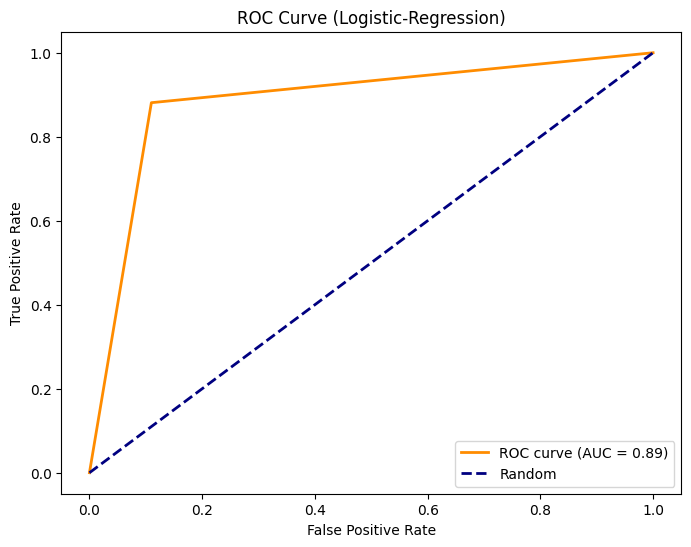

In [18]:
# Compute ROC curve and AUC
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, test_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Logistic-Regression)')
plt.legend(loc='lower right')
plt.show()

In [19]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, test_pred)
cm

array([[3355,  414],
       [ 441, 3265]])

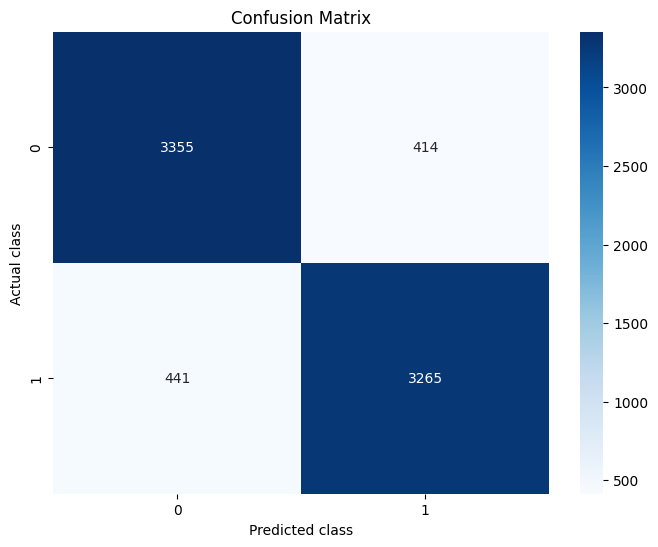

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title('Confusion Matrix')
plt.show()

In [21]:
from sklearn.model_selection import cross_val_predict, cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Define your classifiers
classifiers = {
    'DT': DecisionTreeClassifier(max_depth=6),
    'RF': RandomForestClassifier(n_estimators=42, random_state=42),
    'LRC': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2),
    'GB': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    'XGB': XGBClassifier(booster = 'gbtree', max_depth = 6, gamma=0,min_child_weight = 1,subsample = 1.0, colsample_bytree = 1.0),
    #'SVM': svm.SVC(kernel='linear'),
    #'BR': BaggingClassifier(estimator=SVC(),n_estimators=10, random_state=0)  
}

# Define your data (X) and labels (y)
X = X_train_final.values
y = y_train_final.values
#X = x_train_pca
#y = y_train

# Set up your k-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Initialize dictionaries to store metrics for each classifier
metrics = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'npv': [], 'fpr': [], 'tpr': [], 'roc_auc': []} for name in classifiers}

cf_matrix = dict.fromkeys(classifiers.keys())
# Perform k-fold cross-validation for each classifier
for name, classifier in classifiers.items():
    for train_index, test_index in kfold.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Train the classifier
        classifier.fit(X_train, y_train)
        
        # Make predictions
        y_pred = classifier.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Calculate confusion matrix
        cf_matrix[name]=confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value (Precision)
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
               
        # Append metrics to respective lists
        metrics[name]['accuracy'].append(accuracy)
        metrics[name]['precision'].append(precision)
        metrics[name]['recall'].append(recall)
        metrics[name]['f1_score'].append(f1)
        #metrics[name]['ppv'].append(ppv)
        metrics[name]['npv'].append(npv) 
        fpr, tpr, thresholds = roc_curve(y_test, y_pred)
        metrics[name]['fpr'].append(fpr)
        metrics[name]['tpr'].append(tpr)
        roc_auc = auc(fpr, tpr)
        metrics[name]['roc_auc'].append(roc_auc)

# Calculate mean of metrics across all folds for each classifier
mean_metrics = {name: {metric: sum(values) / len(values) for metric, values in metrics.items()} for name, metrics in metrics.items()}


In [22]:
result=pd.DataFrame(mean_metrics)
result=result.T

In [23]:
result

,accuracy,precision,recall,f1_score,npv,fpr,tpr,roc_auc
DT,0.702576,0.669936,0.798829,0.728576,0.751245,"[0.0, 0.3934912455800334, 1.0]","[0.0, 0.7988286664193194, 1.0]",0.702669
RF,0.91017,0.893682,0.931017,0.91196,0.928048,"[0.0, 0.11069071795083492, 1.0]","[0.0, 0.9310174837982533, 1.0]",0.910163
LRC,0.692862,0.690882,0.698245,0.694433,0.69503,"[0.0, 0.3123908103460586, 1.0]","[0.0, 0.6982446066909291, 1.0]",0.692927
KNN,0.858995,0.794534,0.96833,0.872845,0.959558,"[0.0, 0.25038101921735106, 1.0]","[0.0, 0.9683296328299192, 1.0]",0.858974
GB,0.946616,0.962071,0.929958,0.945734,0.932141,"[0.0, 0.03673011384157683, 1.0]","[0.0, 0.929957877062812, 1.0]",0.946614
XGB,0.890222,0.896996,0.881838,0.889283,0.883738,"[0.0, 0.10126756723638289, 1.0]","[0.0, 0.8818379766721076, 1.0]",0.890285


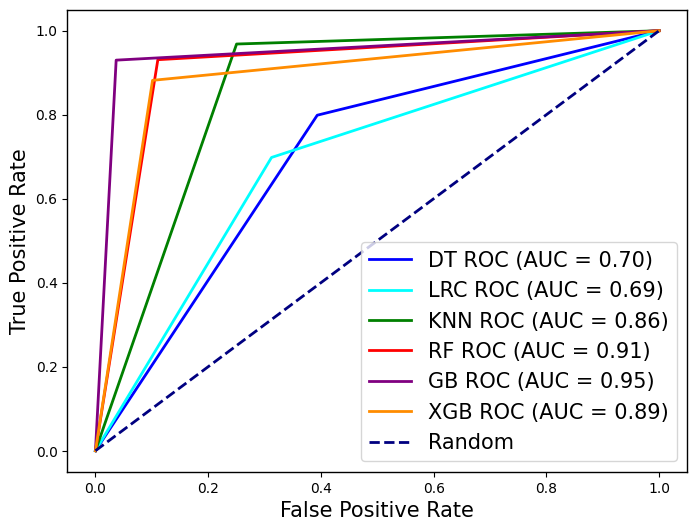

In [24]:
plt.figure(figsize=(8, 6))
#fig, axs = plt.subplots(2, 2)
plt.rcParams['axes.facecolor'] = 'white'
#fig.patch.set_facecolor('white')

#ax.set_facecolor('white')
plt.plot(mean_metrics['DT']['fpr'], mean_metrics['DT']['tpr'],color='blue',lw=2, label='DT ROC (AUC = %0.2f)' % (mean_metrics['DT']['roc_auc']))
plt.plot(mean_metrics['LRC']['fpr'], mean_metrics['LRC']['tpr'],color='cyan',lw=2, label='LRC ROC (AUC = %0.2f)' % (mean_metrics['LRC']['roc_auc']))
plt.plot(mean_metrics['KNN']['fpr'], mean_metrics['KNN']['tpr'],color='green',lw=2, label='KNN ROC (AUC = %0.2f)' % (mean_metrics['KNN']['roc_auc']))
plt.plot(mean_metrics['RF']['fpr'], mean_metrics['RF']['tpr'],color='red',lw=2, label='RF ROC (AUC = %0.2f)' % (mean_metrics['RF']['roc_auc']))
plt.plot(mean_metrics['GB']['fpr'], mean_metrics['GB']['tpr'],color='purple',lw=2, label='GB ROC (AUC = %0.2f)' % (mean_metrics['GB']['roc_auc']))
plt.plot(mean_metrics['XGB']['fpr'], mean_metrics['XGB']['tpr'],color='darkorange',lw=2, label='XGB ROC (AUC = %0.2f)' % (mean_metrics['XGB']['roc_auc']))

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_color('black')  # Change the border color
    spine.set_linewidth(1)  # Change the border thickness

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate', fontsize=15)
plt.ylabel('True Positive Rate', fontsize=15)
#plt.title('ROC Curve (Logistic-Regression)')
plt.legend(loc='lower right', fontsize=15)
plt.show()



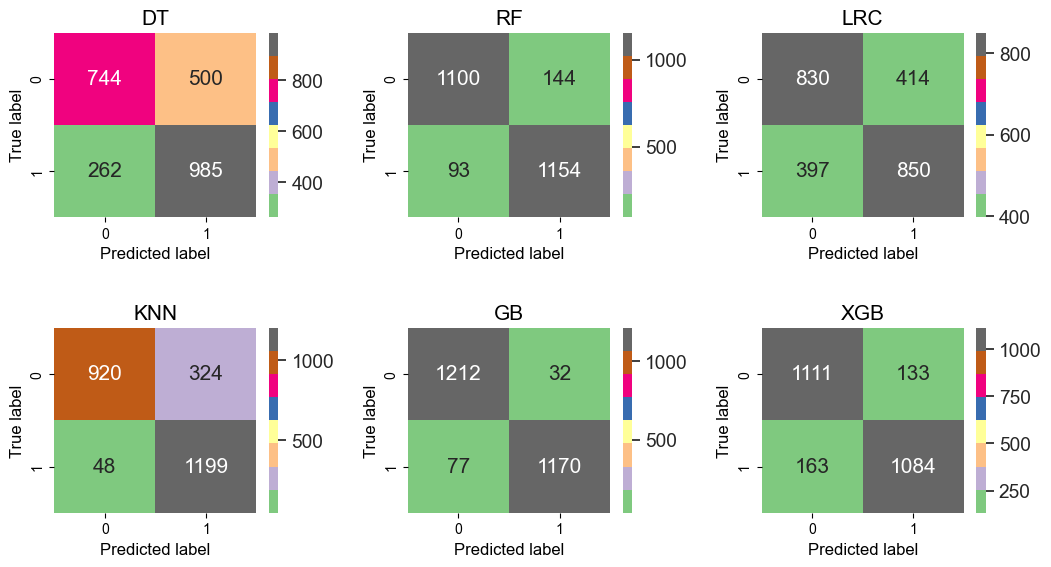

In [25]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

n_algorithms = len(cf_matrix)

fig, axs = plt.subplots(2, 3, figsize=(6 * 2, 6))
#fig, axs = plt.subplots(2,4, sharex=True, sharey='row',figsize=(20,8))
sns.set(font_scale=1.25) # Adjust to fit
for i, algo_data in enumerate(cf_matrix):
    df_cm = pd.DataFrame(cf_matrix[algo_data], index=[j for j in "01"],
                         columns=[j for j in "01"])
    sn.heatmap(df_cm, annot=True, ax=axs.flat[i], fmt="d",cmap='Accent')
    axs.flat[i].set_ylabel('True label',fontsize=12)
    axs.flat[i].set_xlabel('Predicted label',fontsize=12)
    axs.flat[i].set_title(algo_data)
    axs.flat[i].label_font = {'size':'10'}
    
# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)
#plt.tight_layout()
plt.show()

In [26]:
for i, algo_data in enumerate(cf_matrix):
    print(cf_matrix[algo_data])

[[744 500]
 [262 985]]
[[1100  144]
 [  93 1154]]
[[830 414]
 [397 850]]
[[ 920  324]
 [  48 1199]]
[[1212   32]
 [  77 1170]]
[[1111  133]
 [ 163 1084]]


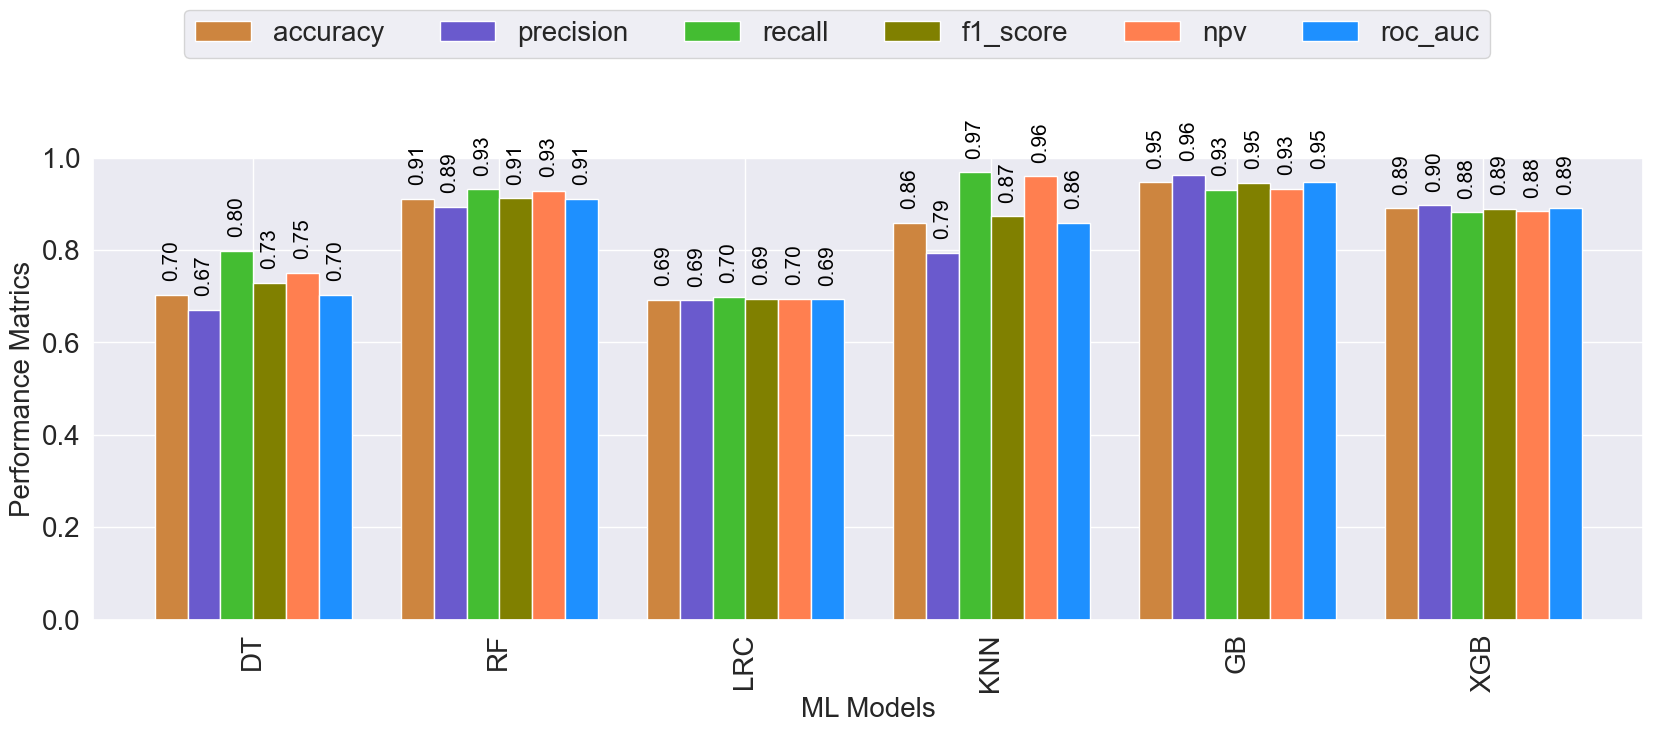

In [27]:
#ax=result.plot(kind='bar', title='',xlabel='ML Models', ylabel='Performance martics', figsize=(14, 5),width=0.8)
ax=result.plot(kind="bar",figsize=(20, 6),width=0.8, fontsize=20, color=['peru', 'slateblue','#44bd32', 'olive', 'coral','dodgerblue'])

for i in ax.containers:
    ax.bar_label(i,rotation=90,fontsize=15,padding=10,label_type='edge',color='black', fmt='%.2f')
    
ax.set_ylim(0, 1)   
# Adding labels to the axes
plt.xlabel('ML Models', fontsize=20)
plt.ylabel('Performance Matrics', fontsize=20)
plt.legend(bbox_to_anchor=(0.91, 1.35), ncol=7, fontsize=20)
#plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.show()

In [28]:

# Define your classifiers
classifiers_GB = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0)

# Define your classifiers
classifiers = {
    '1_Fold': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    '2_Fold': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    '3_Fold': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    '4_Fold': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    '5_Fold': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    '6_Fold': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    '7_Fold': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    '8_Fold': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    '9_Fold': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0),
    '10_Fold':GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=5, random_state=0)
    #'SVM': svm.SVC(kernel='linear'),
    #'BR': BaggingClassifier(estimator=SVC(),n_estimators=10, random_state=0)  
}


# Initialize dictionaries to store metrics for each classifier
metrics_GB = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'npv': [], 'fpr': [], 'tpr': [], 'roc_auc': []} for name in classifiers}

# Define your data (X) and labels (y)
X = X_train_final.values
y = y_train_final.values# Set up your k-fold cross-validation

# Perform k-fold cross-validation for each classifier
i=2
for name, classifier in classifiers.items():
    if(name=='1_Fold'):
        ###!_Fold////
        x_train, x_test, y_train, y_test = train_test_split(X_train_final, y_train_final, test_size=0.30, random_state=42)
        classifiers_GB.fit(x_train, y_train)
        y_pred = classifiers_GB.predict(x_test)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        metrics_GB['1_Fold']['accuracy'].append(accuracy)
        metrics_GB['1_Fold']['precision'].append(precision)
        metrics_GB['1_Fold']['recall'].append(recall)
        metrics_GB['1_Fold']['f1_score'].append(f1)
        metrics_GB['1_Fold']['npv'].append(npv) 
        fpr, tpr, thresholds = roc_curve(y_test, y_pred)
        metrics_GB['1_Fold']['fpr'].append(fpr)
        metrics_GB['1_Fold']['tpr'].append(tpr)
        roc_auc = auc(fpr, tpr)
        metrics_GB['1_Fold']['roc_auc'].append(roc_auc)
    else:
        kfold = KFold(n_splits=i, shuffle=True, random_state=42)
        i=i+1
        for train_index, test_index in kfold.split(X):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Train the classifier
            classifiers_GB.fit(X_train, y_train)

            # Make predictions
            y_pred = classifiers_GB.predict(X_test)

            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)


            # Append metrics to respective lists
            metrics_GB[name]['accuracy'].append(accuracy)
            metrics_GB[name]['precision'].append(precision)
            metrics_GB[name]['recall'].append(recall)
            metrics_GB[name]['f1_score'].append(f1)
            #metrics[name]['ppv'].append(ppv)
            metrics_GB[name]['npv'].append(npv) 
            fpr, tpr, thresholds = roc_curve(y_test, y_pred)
            metrics_GB[name]['fpr'].append(fpr)
            metrics_GB[name]['tpr'].append(tpr)
            roc_auc = auc(fpr, tpr)
            metrics_GB[name]['roc_auc'].append(roc_auc)

    # Calculate mean of metrics across all folds for each classifier
mean_metrics_GB = {name: {metrics_GB: sum(values) / len(values) for metrics_GB, values in metrics_GB.items()} for name, metrics_GB in metrics_GB.items()}

result_gb=pd.DataFrame(mean_metrics_GB)
result_gb=result_gb.T
result_gb

,accuracy,precision,recall,f1_score,npv,fpr,tpr,roc_auc
1_Fold,0.941003,0.952091,0.927685,0.939729,0.872057,"[0.0, 0.04590076943486336, 1.0]","[0.0, 0.9276848354020507, 1.0]",0.940892
2_Fold,0.934214,0.946947,0.920005,0.933276,0.872057,"[0.0, 0.051537827275921155, 1.0]","[0.0, 0.9200051471959872, 1.0]",0.934234
3_Fold,0.939592,0.951037,0.926955,0.938824,0.872057,"[0.0, 0.04776240303085671, 1.0]","[0.0, 0.9269551562741984, 1.0]",0.939596
4_Fold,0.942723,0.956584,0.927604,0.941869,0.872057,"[0.0, 0.042191345549439464, 1.0]","[0.0, 0.9276035069893233, 1.0]",0.942706
5_Fold,0.941478,0.954354,0.927379,0.940669,0.872057,"[0.0, 0.04443275799749158, 1.0]","[0.0, 0.9273794828528305, 1.0]",0.941473
6_Fold,0.943365,0.956037,0.929426,0.942532,0.872057,"[0.0, 0.04268656951104535, 1.0]","[0.0, 0.9294260025487562, 1.0]",0.94337
7_Fold,0.945332,0.959173,0.93024,0.944474,0.872057,"[0.0, 0.03955603956804365, 1.0]","[0.0, 0.9302398944812224, 1.0]",0.945342
8_Fold,0.94493,0.959541,0.929032,0.944024,0.872057,"[0.0, 0.03917137714669069, 1.0]","[0.0, 0.9290315654040898, 1.0]",0.94493
9_Fold,0.946576,0.960931,0.93098,0.945702,0.872057,"[0.0, 0.03779104754940453, 1.0]","[0.0, 0.9309798904604842, 1.0]",0.946594
10_Fold,0.946616,0.962071,0.929958,0.945734,0.872057,"[0.0, 0.03673011384157683, 1.0]","[0.0, 0.929957877062812, 1.0]",0.946614
